# Generator EDA — Phase 1 Validation

Cross-modal consistency check for the synthetic CDT dataset.  
Data generated by `uv run python -m generator.pipeline`.

**Calibration targets (Payne et al. 1993)**

| Archetype | Payne Index | prop_cells | mean_dwell_ms |
|---|---|---|---|
| price_lex | -0.6 to -0.8 | 0.15–0.30 | 800–1200 |
| compensatory | -0.2 to +0.2 | 0.60–0.85 | 1000–1800 |
| satisficer | -0.3 to -0.5 | 0.30–0.55 | 900–1400 |
| brand_affect | -0.7 to -0.9 | 0.10–0.30 | 600–1000 |
| low_involve | -0.1 to +0.1 | 0.20–0.45 | 400–800 |


In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

DATA = Path("../data/synthetic")

trials = pd.DataFrame(
    [json.loads(line) for line in (DATA / "trials.jsonl").read_text().splitlines()]
)
transactions = pd.DataFrame(
    [
        json.loads(line)
        for line in (DATA / "transactions.jsonl").read_text().splitlines()
    ]
)
psychographics = pd.DataFrame(
    [
        json.loads(line)
        for line in (DATA / "psychographics.jsonl").read_text().splitlines()
    ]
)

print(
    f"trials:        {len(trials):,} rows across {trials['persona_id'].nunique()} archetypes"
)
print(f"transactions:  {len(transactions):,} rows")
print(f"psychographics: {len(psychographics):,} rows")

trials:        2,800 rows across 7 archetypes
transactions:  5,568 rows
psychographics: 140 rows


## 1. Payne Index distributions by archetype

/tmp/ipykernel_189140/1856475635.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_arch, labels=archetype_order, patch_artist=True)


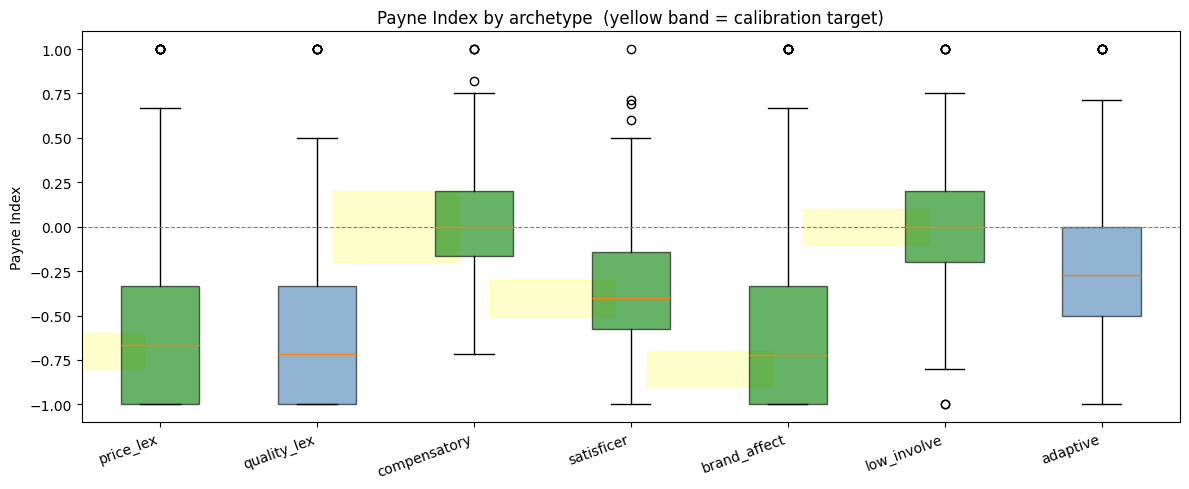


Median Payne Index vs calibration targets:
  price_lex       median=-0.667  target=[-0.8,-0.6]  ✓ PASS
  quality_lex     median=-0.714  (no target)
  compensatory    median=+0.000  target=[-0.2,0.2]  ✓ PASS
  satisficer      median=-0.400  target=[-0.5,-0.3]  ✓ PASS
  brand_affect    median=-0.724  target=[-0.9,-0.7]  ✓ PASS
  low_involve     median=+0.000  target=[-0.1,0.1]  ✓ PASS
  adaptive        median=-0.273  (no target)


In [2]:
# Calibration ranges for Payne Index
PAYNE_RANGES = {
    "price_lex": (-0.8, -0.6),
    "compensatory": (-0.2, 0.2),
    "satisficer": (-0.5, -0.3),
    "brand_affect": (-0.9, -0.7),
    "low_involve": (-0.1, 0.1),
}

archetype_order = [
    "price_lex",
    "quality_lex",
    "compensatory",
    "satisficer",
    "brand_affect",
    "low_involve",
    "adaptive",
]

fig, ax = plt.subplots(figsize=(12, 5))
data_by_arch = [
    trials[trials["persona_id"] == a]["payne_index"].values for a in archetype_order
]
bp = ax.boxplot(data_by_arch, labels=archetype_order, patch_artist=True)

# Colour boxes: green if within range, red if not (for archetypes with targets)
colors = []
for arch, patch in zip(archetype_order, bp["boxes"]):
    if arch in PAYNE_RANGES:
        lo, hi = PAYNE_RANGES[arch]
        med = trials[trials["persona_id"] == arch]["payne_index"].median()
        colors.append("green" if lo <= med <= hi else "red")
    else:
        colors.append("steelblue")
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.6)

# Draw calibration range bands
for i, arch in enumerate(archetype_order, 1):
    if arch in PAYNE_RANGES:
        lo, hi = PAYNE_RANGES[arch]
        ax.axhspan(
            lo,
            hi,
            xmin=(i - 1.4) / len(archetype_order),
            xmax=(i - 0.6) / len(archetype_order),
            color="yellow",
            alpha=0.2,
            zorder=0,
        )

ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_ylabel("Payne Index")
ax.set_title("Payne Index by archetype  (yellow band = calibration target)")
ax.set_ylim(-1.1, 1.1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("payne_index_by_archetype.png", dpi=120)
plt.show()

# Print median + pass/fail
print("\nMedian Payne Index vs calibration targets:")
for arch in archetype_order:
    med = trials[trials["persona_id"] == arch]["payne_index"].median()
    if arch in PAYNE_RANGES:
        lo, hi = PAYNE_RANGES[arch]
        status = "✓ PASS" if lo <= med <= hi else "✗ FAIL"
        print(f"  {arch:<15} median={med:+.3f}  target=[{lo},{hi}]  {status}")
    else:
        print(f"  {arch:<15} median={med:+.3f}  (no target)")

## 2. prop_cells_inspected by archetype

/tmp/ipykernel_189140/2737813098.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_arch, labels=archetype_order, patch_artist=True)


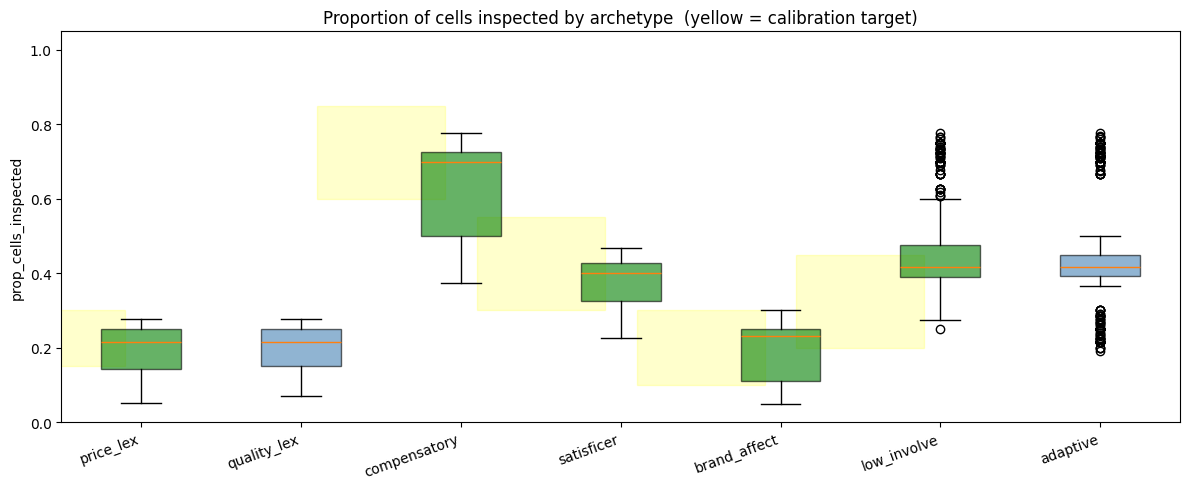


Median prop_cells vs calibration targets:
  price_lex       median=0.214  target=[0.15,0.3]  ✓ PASS
  quality_lex     median=0.214  (no target)
  compensatory    median=0.700  target=[0.6,0.85]  ✓ PASS
  satisficer      median=0.400  target=[0.3,0.55]  ✓ PASS
  brand_affect    median=0.232  target=[0.1,0.3]  ✓ PASS
  low_involve     median=0.417  target=[0.2,0.45]  ✓ PASS
  adaptive        median=0.417  (no target)


In [3]:
PROP_RANGES = {
    "price_lex": (0.15, 0.30),
    "compensatory": (0.60, 0.85),
    "satisficer": (0.30, 0.55),
    "brand_affect": (0.10, 0.30),
    "low_involve": (0.20, 0.45),
}

fig, ax = plt.subplots(figsize=(12, 5))
data_by_arch = [
    trials[trials["persona_id"] == a]["prop_cells_inspected"].values
    for a in archetype_order
]
bp = ax.boxplot(data_by_arch, labels=archetype_order, patch_artist=True)

colors = []
for arch, patch in zip(archetype_order, bp["boxes"]):
    if arch in PROP_RANGES:
        lo, hi = PROP_RANGES[arch]
        med = trials[trials["persona_id"] == arch]["prop_cells_inspected"].median()
        colors.append("green" if lo <= med <= hi else "red")
    else:
        colors.append("steelblue")
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.6)

for i, arch in enumerate(archetype_order, 1):
    if arch in PROP_RANGES:
        lo, hi = PROP_RANGES[arch]
        ax.axhspan(
            lo,
            hi,
            xmin=(i - 1.4) / len(archetype_order),
            xmax=(i - 0.6) / len(archetype_order),
            color="yellow",
            alpha=0.2,
            zorder=0,
        )

ax.set_ylabel("prop_cells_inspected")
ax.set_title(
    "Proportion of cells inspected by archetype  (yellow = calibration target)"
)
ax.set_ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("prop_cells_by_archetype.png", dpi=120)
plt.show()

print("\nMedian prop_cells vs calibration targets:")
for arch in archetype_order:
    med = trials[trials["persona_id"] == arch]["prop_cells_inspected"].median()
    if arch in PROP_RANGES:
        lo, hi = PROP_RANGES[arch]
        status = "✓ PASS" if lo <= med <= hi else "✗ FAIL"
        print(f"  {arch:<15} median={med:.3f}  target=[{lo},{hi}]  {status}")
    else:
        print(f"  {arch:<15} median={med:.3f}  (no target)")

## 3. Price paid normalised vs price sensitivity

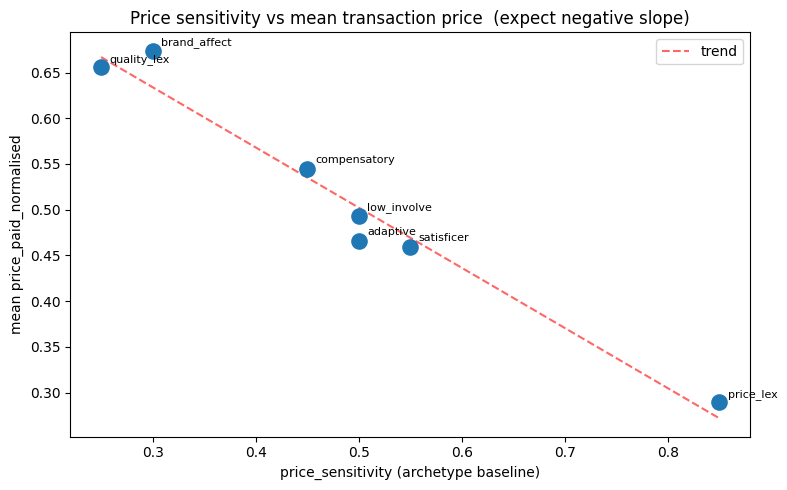

Pearson r(price_sensitivity, mean_price_paid) = -0.982  (expect < 0)


In [4]:
# Merge psychographics (price_sensitivity) with transaction price data
tx_mean = (
    transactions.groupby("persona_id")["price_paid_normalised"].mean().reset_index()
)
tx_mean.columns = ["persona_id", "mean_price_paid"]
ps_vals = (
    psychographics.groupby("persona_id")
    .agg(
        price_consciousness=("price_consciousness", "mean"),
    )
    .reset_index()
)
merged = tx_mean.merge(ps_vals, on="persona_id")

# Also get price_sensitivity from trials persona_id → use PersonaConfig knowledge
price_sens = {
    "price_lex": 0.85,
    "quality_lex": 0.25,
    "compensatory": 0.45,
    "satisficer": 0.55,
    "brand_affect": 0.30,
    "low_involve": 0.50,
    "adaptive": 0.50,
}
merged["price_sensitivity"] = merged["persona_id"].map(price_sens)

fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(
    merged["price_sensitivity"], merged["mean_price_paid"], s=120, zorder=3
)
for _, row in merged.iterrows():
    ax.annotate(
        row["persona_id"],
        (row["price_sensitivity"], row["mean_price_paid"]),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=8,
    )

# Expected negative correlation
z = np.polyfit(merged["price_sensitivity"], merged["mean_price_paid"], 1)
xs = np.linspace(
    merged["price_sensitivity"].min(), merged["price_sensitivity"].max(), 50
)
ax.plot(xs, np.polyval(z, xs), "r--", alpha=0.6, label="trend")
ax.set_xlabel("price_sensitivity (archetype baseline)")
ax.set_ylabel("mean price_paid_normalised")
ax.set_title("Price sensitivity vs mean transaction price  (expect negative slope)")
ax.legend()
plt.tight_layout()
plt.savefig("price_sensitivity_vs_price_paid.png", dpi=120)
plt.show()

corr = merged[["price_sensitivity", "mean_price_paid"]].corr().iloc[0, 1]
print(f"Pearson r(price_sensitivity, mean_price_paid) = {corr:.3f}  (expect < 0)")

## 4. Psychographic score distributions

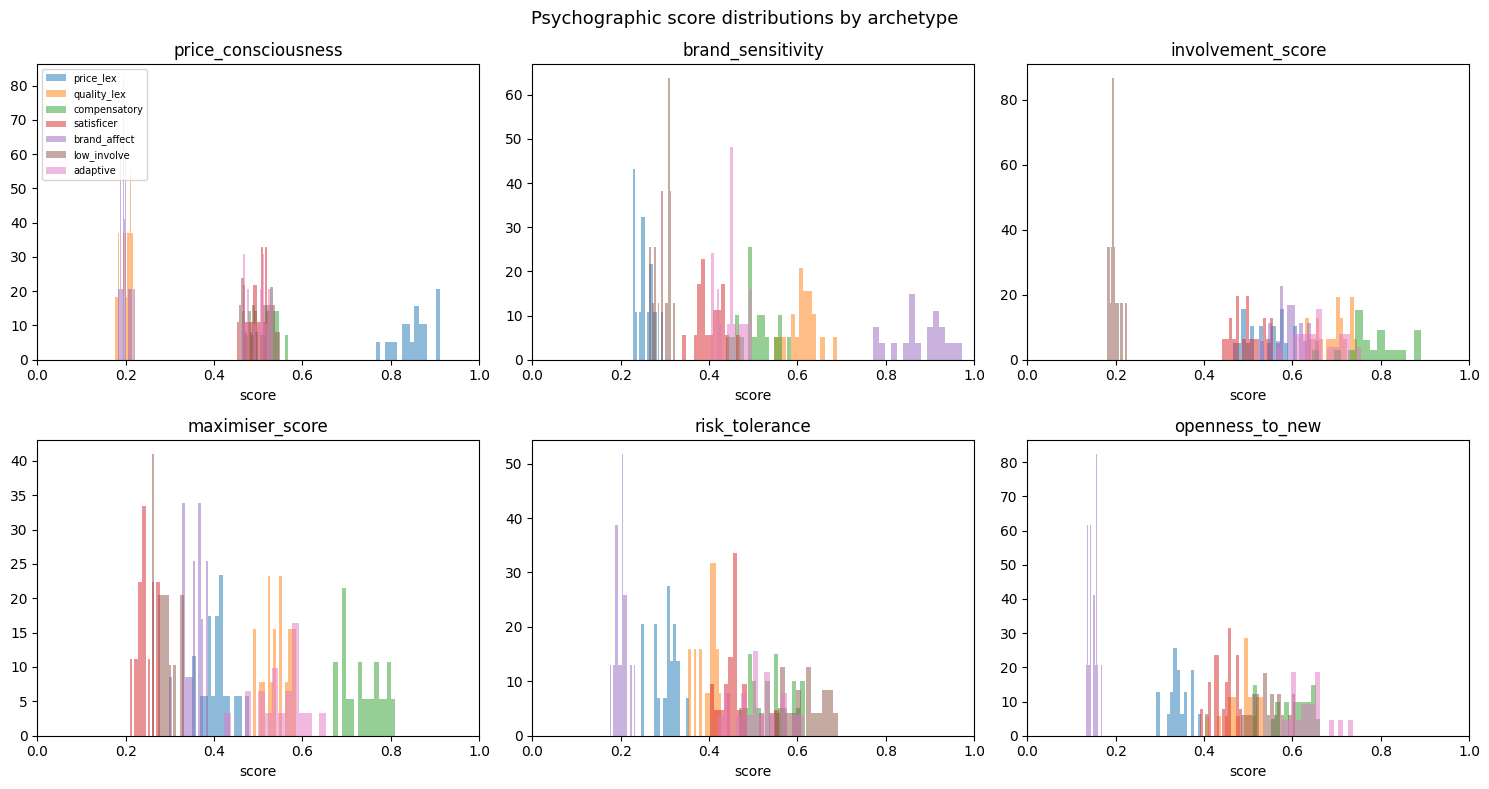


Mean psychographic scores by archetype:
              price_consciousness  brand_sensitivity  involvement_score  maximiser_score  risk_tolerance  openness_to_new
persona_id                                                                                                               
adaptive                    0.499              0.450              0.662            0.549           0.511            0.637
brand_affect                0.198              0.879              0.594            0.355           0.200            0.148
compensatory                0.511              0.506              0.786            0.737           0.541            0.600
low_involve                 0.501              0.297              0.196            0.292           0.609            0.545
price_lex                   0.852              0.254              0.538            0.409           0.301            0.346
quality_lex                 0.202              0.613              0.690            0.543           0.399 

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
score_cols = [
    "price_consciousness",
    "brand_sensitivity",
    "involvement_score",
    "maximiser_score",
    "risk_tolerance",
    "openness_to_new",
]

for ax, col in zip(axes.flat, score_cols):
    for arch in archetype_order:
        vals = psychographics[psychographics["persona_id"] == arch][col]
        ax.hist(vals, bins=15, alpha=0.5, label=arch, density=True)
    ax.set_title(col)
    ax.set_xlabel("score")
    ax.set_xlim(0, 1)

axes.flat[0].legend(fontsize=7, loc="upper left")
plt.suptitle("Psychographic score distributions by archetype", fontsize=13)
plt.tight_layout()
plt.savefig("psychographic_distributions.png", dpi=120)
plt.show()

print("\nMean psychographic scores by archetype:")
print(psychographics.groupby("persona_id")[score_cols].mean().round(3).to_string())

## 5. Summary: calibration range violations

In [6]:
print("=" * 60)
print("CALIBRATION SUMMARY")
print("=" * 60)

all_passed = True

for arch in archetype_order:
    arch_trials = trials[trials["persona_id"] == arch]
    violations = []

    if arch in PAYNE_RANGES:
        lo, hi = PAYNE_RANGES[arch]
        med_pi = arch_trials["payne_index"].median()
        if not (lo <= med_pi <= hi):
            violations.append(f"Payne Index median={med_pi:.3f} outside [{lo},{hi}]")

    if arch in PROP_RANGES:
        lo, hi = PROP_RANGES[arch]
        med_pc = arch_trials["prop_cells_inspected"].median()
        if not (lo <= med_pc <= hi):
            violations.append(f"prop_cells median={med_pc:.3f} outside [{lo},{hi}]")

    if violations:
        all_passed = False
        print(f"\n✗ {arch}:")
        for v in violations:
            print(f"    {v}")
    else:
        print(f"✓ {arch}: all checks passed")

print()
if all_passed:
    print("ALL ARCHETYPES WITHIN CALIBRATION TARGETS — Phase 2 may begin.")
else:
    print("CALIBRATION FAILURES DETECTED — review generator parameters before Phase 2.")

CALIBRATION SUMMARY
✓ price_lex: all checks passed
✓ quality_lex: all checks passed
✓ compensatory: all checks passed
✓ satisficer: all checks passed
✓ brand_affect: all checks passed
✓ low_involve: all checks passed
✓ adaptive: all checks passed

ALL ARCHETYPES WITHIN CALIBRATION TARGETS — Phase 2 may begin.
